In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('/cluster/scratch/vogtva/data/bruss/final/_dataset_times.csv')
ds = xr.open_dataset('/cluster/work/math/vogtva/data/bruss/final/_dataset.nc')

In [3]:
df_sub = df.sample(200)

<Axes: xlabel='settling_time', ylabel='Count'>

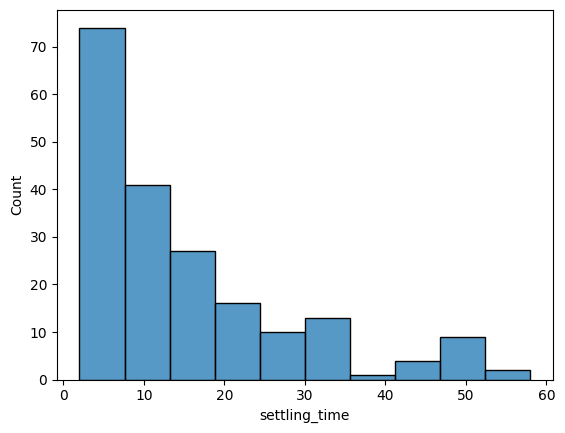

In [4]:
sns.histplot(df_sub[df_sub.settling_time < 60].settling_time)

In [5]:
arrs = []
for i, row in df_sub.iterrows():
    data = ds["data"][row.idx]
    if row.settling_time < 10:
        sel = data[:10]
    else:
        indices = np.linspace(0, row.settling_time - 1, num=10, dtype=int)
        sel = data[indices]
    
    arrs.append(sel)

In [18]:
stacked = np.stack(arrs)
stacked = np.stack([stacked[:,:,:,0::2], stacked[:,:,:,1::2]], axis=2)
stacked = stacked[:,:,:,1:-1,1:-1]
stacked.shape

(200, 10, 2, 128, 128)

In [14]:
data = stacked

# Compute discrete time derivative
dt_data = np.diff(data, axis=1)  # shape: [B, n_snap-1, Nx, 2Ny]

dt_norm = np.linalg.norm(dt_data, axis=(2, 3))  # [B, n_snap-1]
max_dt = dt_norm.max(axis=1, keepdims=True)
rel_dt_norm = dt_norm / max_dt  # relative norms

def find_settling_time(norms, thresh):
    for t in range(len(norms)):
        if np.all(norms[t:] < thresh):
            return t + 1
    return len(norms)

# settling_times = [find_settling_time(rel_dt_norm[i], threshold) for i in range(end - start)]

# settling_times_all.extend(settling_times)
# rel_dt_norm_all.extend(rel_dt_norm)

In [8]:
# n_traj = stacked.shape[0]
# n_cols = 5
# n_rows = int(np.ceil(n_traj / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
# axes = axes.flatten()

# for i in range(n_traj):
#     ax = axes[i]
#     ax.plot(rel_dt_norm[i], label="rel. ∂/∂t norm")
#     ax.axvline(df.settling_time[i] - 1, color='r', linestyle='--', label="settling time")
#     ax.set_title(f"Trajectory {i}")
#     ax.set_xlabel("Snapshot")
#     ax.set_ylabel("Relative ∂/∂t norm")
#     # ax.set_yscale('log')
#     ax.legend(fontsize="small")

# # Hide unused axes
# for j in range(n_traj, len(axes)):
#     axes[j].axis('off')

# plt.tight_layout()
# plt.show()


In [10]:
# template = ds["data"].isel(component=0)
data_with_param = stacked
for var in ["A", "B", "Du", "Dv"]:
    param_vals = np.array(df_sub[var])
    param_comp = np.ones_like(stacked[:, :, 0])
    param_comp *= param_vals[:, np.newaxis, np.newaxis, np.newaxis]
    data_with_param = np.concatenate([data_with_param, param_comp[:,:,np.newaxis]], axis=2)

dims = ("run", "snapshot", "component", "Nx", "Ny")
ds_final = xr.Dataset(
    data_vars={
        "data": (dims, data_with_param),
    }
)

In [11]:
ds_final.to_netcdf('/cluster/scratch/vogtva/data/bruss/final/_rescaled.nc')